**Connecting to Drive**

In [ ]:
#dataset folder
import os
import pandas as pd
import re
import json

video_folder = '/data/videos'  #folder path
video_files = [os.path.join(video_folder, f) for f in os.listdir(video_folder) if f.endswith(('.mp4', '.mov', '.avi'))]

print(f"Found {len(video_files)} videos:")
for f in video_files:
    print(f"- {f}")

**Installing dependencies**

In [ ]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

PyTorch Version: 2.8.0+cu126
CUDA Available: True
GPU Name: NVIDIA A100-SXM4-80GB


**Loading the model from hugginface**

In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch


#7B Parameter
# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype="auto", device_map="auto"
)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
#model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     "Qwen/Qwen2.5-VL-3B-Instruct",
#     torch_dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
#    device_map="auto" )

# default processer
#processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

#7B
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")


# The default range for the number of visual tokens per image in the model is 4-16384.
# You can set min_pixels and max_pixels according to your needs, such as a token range of 256-1280, to balance performance and cost.
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)

print("Model and Processor Loaded Successfully!")


**Preview the video files**

In [ ]:
# Video list
import os

video_folder2 = '/videos/dataset'
video_files2 = [os.path.join(video_folder2, f) for f in os.listdir(video_folder2) if f.endswith(('.mp4', '.mov', '.avi'))]

print(f"Found {len(video_files2)} videos:")
for f in video_files2:
    print(f"- {f}")

In [ ]:
from IPython.display import Video

# Preview the video
path2 = video_files2[5]
import os
print(os.path.exists(path2))
print(f"file://{path2}")
#print(f"file://{path2}")


In [ ]:
Video(path2, embed=True, width=480, height=360)


**Task Detection prompt**

In [ ]:
TASK_DETECTION_PROMPT = """You are an expert WMFT task detector. Analyze the video to identify which ONE WMFT task is being performed using precise visual setup markers.

## CRITICAL INSTRUCTION: COMPLETE VIDEO ANALYSIS
Watch the ENTIRE video from start to finish before making ANY decisions.

## STEP 1: PRECISE VISUAL SETUP ANALYSIS

### **PHASE 1: CRITICAL OBJECT DETECTION**

**CYAN/TEAL BOTTLE DETECTION (Most Critical):**
- Look for CYAN/TEAL colored bottle on table
- Bottle is cylindrical, approximately 10cm tall
- May be on table surface
- **If ANY cyan/teal bottle visible -> Extend elbow with weight**
- **If NO cyan/teal bottle anywhere -> Extend elbow (if lateral movement)**

**ELEVATED BOX DETECTION (Most Critical):**
- Look for BOX on table
- Box creates a clear STEP-UP above the white table surface
- Box appears as a distinct raised platform, NOT just table edge
- **If elevated BOX visible -> Side sitting arm to box**
- **If only flat white table surface -> Side sitting arm to table**

### **PHASE 2: DISCRETE OBJECT IDENTIFICATION**

**THREE OBJECT TASKS:**
- **Stack checkers**: 3 ROUND colored objects (visible: red, green, other colors)
- **Flip cards**: 3 RECTANGULAR flat objects with markings

**SINGLE OBJECT TASKS:**
- **Turn key**: Blue mechanical apparatus with sliding red arrow
- **Lifting can**: Single cylindrical can
- **Lift pencil**: Single pencil

## STEP 2: ENHANCED TASK IDENTIFICATION

### **ELBOW EXTENSION TASKS (Patient sits side along to table):**

### 2. **Extend elbow with weight**
**CRITICAL VISUAL MARKERS:**
- **CYAN/TEAL BOTTLE must be clearly visible**
- Patient sits with side along table length
- Lateral pushing motion across white gridded table
- Bottle may start on table surface
- Hand moves sideways to reach target line
**ABSOLUTE RULE:** No cyan bottle = NOT this task

### 3. **Extend elbow**
**CRITICAL VISUAL MARKERS:**
- **NO cyan/teal bottle anywhere in frame**
- Patient sits with side along table length
- Lateral arm extension across white gridded table
- Hand moves sideways to reach target line
**ABSOLUTE RULE:** If cyan bottle present = Extend elbow with weight

### **SIDE SITTING TASKS (Patient sits PERPENDICULAR to table):**

### 5. **Side sitting arm to box**
**CRITICAL VISUAL MARKERS:**
- **BOX is clearly visible on table**
- Platform creates distinct step above white table surface
- Patient sits sideways to table edge
- Forward reach from lap to elevated BOX
**ABSOLUTE RULE:** No elevated platform = Side sitting arm to table

### 4. **Side sitting arm to table**
**CRITICAL VISUAL MARKERS:**
- **ONLY flat white table surface visible (no elevated platform)**
- Patient sits sideways to table edge
- Forward reach from lap to standard white table
- No dark platform or box above table level
**ABSOLUTE RULE:** If elevated platform present = Side sitting arm to box

### **OBJECT MANIPULATION TASKS:**

### 1. **Turn key**
- Blue mechanical apparatus with key shaft and red sliding arrow

### 6. **Lifting can**
- Single cylindrical container (NOT the cyan bottle)

### 7. **Lift pencil**
- Single pencil picking up from the table and lifting

### 8. **Flip cards**
- EXACTLY 3 rectangular flat objects or cards with printed markings

### 9. **Stack checkers**
- EXACTLY 3 round colored objects (visible: red, green, other colors)

## STEP 3: ENHANCED VERIFICATION RULES

### **CYAN BOTTLE VERIFICATION:**
- [ ] Scanned entire video frame for cyan/teal colored bottle
- [ ] Checked table surface, patient's hands, nearby areas
- [ ] Confirmed bottle presence/absence before classifying elbow tasks
- **Decision:** Cyan bottle = Extend elbow with weight | No bottle = Extend elbow

### **ELEVATED PLATFORM VERIFICATION:**
- [ ] Looked for dark blue/black raised platform on white table
- [ ] Confirmed platform creates clear step above table surface
- [ ] Distinguished between flat table and elevated surface
- **Decision:** Dark platform = Side sitting arm to box | Flat table = Side sitting arm to table

### **POSITION VERIFICATION:**
- [ ] Determined patient sitting position relative to table
- **Parallel to table** (side along length) = Elbow extension tasks
- **Perpendicular to table** (facing edge) = Side sitting arm tasks

### **OBJECT COUNT VERIFICATION:**
- [ ] Counted discrete manipulable objects
- **1 object** = Turn key, Lifting can, or Lift pencil
- **3 objects** = Flip cards (rectangular) or Stack checkers (round)

## STEP 4: CRITICAL ANTI-CONFUSION RULES

**PREVENT: "Side sitting arm to box" -> "Extend elbow":**
- Look for DARK ELEVATED PLATFORM first
- If dark platform visible = Side sitting arm to box (NOT extend elbow)
- Position analysis: perpendicular = side sitting tasks

**PREVENT: "Extend elbow with weight" → "Extend elbow":**
- Look for CYAN/TEAL BOTTLE first
- If cyan bottle visible = Extend elbow with weight (NOT extend elbow)
- Bottle color is key distinguishing feature

**PRESERVE CURRENT SUCCESSES:**
- Object-first approach for single items (pencil, can)
- Shape analysis for 3-object tasks (round vs rectangular)

## STEP 5: DECISION PRIORITY FLOWCHART

1. **Count objects**: 1 object -> identify type | 3 objects -> identify shape
2. **If no discrete objects**: Check for cyan bottle and elevated platform
3. **Cyan bottle present** -> Extend elbow with weight
4. **Elevated platform present** -> Side sitting arm to box
5. **Neither present**: Use position analysis for remaining tasks

Return ONLY this JSON format:
{
  "task_id": <number>,
  "task_name": "<task_name>",
  "confidence": <float between 0 and 1>
}"""

**Scoring prompt**

In [ ]:
def get_scoring_prompt(task_id, task_name):
    """WMFT-aligned scoring prompt with official criteria"""

    completion_criteria = {
        1: "Red arrow reaches BOTH end-stops",
        2: "Hand/bottle crosses target line",
        3: "Hand crosses target line",
        4: "Forearm rests flat on table surface",
        5: "Forearm rests flat on elevated box",
        6: "Can lifted to mouth/chin level",
        7: "Pencil completely off table",
        8: "All 3 cards successfully flipped",
        9: "Stable vertical tower of 3 checkers"
    }

    return f"""Score movement quality for WMFT Task {task_id}: {task_name}

## OFFICIAL WMFT SCORING CRITERIA (0-5 SCALE):

**Score 0 - No movement**:
- Patient does not attempt the movement
- Shows no voluntary movement of the target limb

**Score 1 - Minimal movement**:
- Patient initiates movement but CANNOT complete the task
- Movement may be primarily compensatory using trunk or other body segments

**Score 2 - Poor movement**:
- Patient COMPLETES the task but with significant difficulty
- Excessive compensatory movements or abnormal movement patterns

**Score 3 - Fair movement**:
- Patient COMPLETES the task with some difficulty
- Minor compensatory movements present
- Movement quality noticeably different from normal but functional
- **IMPORTANT: If patient bumps/hits the table → Score 3 maximum**

**Score 4 - Good movement**:
- Patient COMPLETES the task with minimal difficulty
- Only slight deviations from normal movement patterns

**Score 5 - Normal movement**:
- Patient performs task with normal movement quality, speed, and efficiency

## TASK COMPLETION REQUIREMENT:
**{task_name}**: {completion_criteria.get(task_id, "Task completion")}

## CRITICAL SCORING DECISION PROCESS:

### STEP 1: Check for movement attempt
- No attempt at all -> **Score 0**
- Any voluntary movement -> Continue to Step 2

### STEP 2: Check task completion
- Task NOT completed -> **Score 1** (initiated but failed)
- Task completed -> Continue to Step 3

### STEP 3: Assess movement quality (if completed)

**Look for these indicators:**

**MAJOR PROBLEMS (-> Score 2):**
- Excessive trunk lean/compensation
- Multiple failed attempts before success
- Severe tremor or instability
- Abnormal movement patterns throughout
- Very slow, laborious movement
- Uses other hand to assist affected limb

**MODERATE PROBLEMS (-> Score 3):**
- Some trunk compensation
- Mild to moderate tremor
- **Bumps or hits the table during movement**
- Noticeable difficulty but functional
- Minor use of momentum/swinging
- Slightly abnormal posture
- Takes longer than normal but manageable

**MINOR PROBLEMS (-> Score 4):**
- Minimal trunk involvement
- Slight hesitation or slowness
- Very mild tremor
- Nearly normal pattern with small deviations
- Completes smoothly with minor adjustments

**NO PROBLEMS (-> Score 5):**
- Normal speed and fluidity
- No compensations
- Natural movement pattern
- Efficient and smooth execution

## IMPORTANT REMINDERS:
1. Scores 0-1: Task NOT completed
2. Scores 2-5: Task IS completed (quality varies)
3. Table bumping/hitting automatically limits score to 3 maximum
4. Most stroke patients score between 1-3
5. Score 5 is rare - requires completely normal movement
6. When uncertain between scores, choose the LOWER one

## AVOID THESE SCORING ERRORS:
- Don't give score 2 if task wasn't completed (should be 0 or 1)
- Don't give score 4 if obvious compensations present
- Don't default to score 4 - it requires near-normal movement
- Remember: bumping table = score 3 maximum regardless of other factors

Return ONLY this JSON format:
{{
  "completion_met": <true/false>,
  "score": <0-5>,
  "movement_quality": "<describe exactly what you observed>",
  "compensations": ["<list specific compensations: trunk lean, shoulder hiking, etc>"],
  "score_justification": "<explain using official criteria why this exact score>"
}}"""

**Binding inference to the model**

In [ ]:
def message_run_stage1(path):
    messages = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": TASK_DETECTION_PROMPT
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "video",
                    "video": f"file://{path}",
                    "max_pixels": 640*360,
                    "fps": 3.0,
                },
                {
                    "type": "text",
                    "text": "What WMFT task is the patient performing in this video? Return only the JSON format requested."
                },
            ],
        }
    ]
    return messages

def message_run_stage2(path, task_id, task_name):
    scoring_prompt = get_scoring_prompt(task_id, task_name)

    messages = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": scoring_prompt
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "video",
                    "video": f"file://{path}",
                    "max_pixels": 640*360,
                    "fps": 3.0,
                },
                {
                    "type": "text",
                    "text": f"Score the movement quality for {task_name}. Watch the complete video and assess both completion and movement quality. Return only the JSON format requested."
                },
            ],
        }
    ]
    return messages

**Running the model**

In [ ]:
def model_run(messages, max_tokens=256):
    # In Qwen 2.5 VL, frame rate information is also input into the model to align with absolute time.
    # Preparation for inference

    #Applying chat template converts into chat style input
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    #Extract input from messages converts them to tensors
    image_inputs, video_inputs = process_vision_info(messages)

    #Bind eveything together
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")

    # Inference
    generated_ids = model.generate(**inputs, max_new_tokens=max_tokens)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text

In [ ]:
def parse_task_detection(output_string):
    try:
        # Handle list format output
        if isinstance(output_string, list) and len(output_string) > 0:
            output_string = output_string[0]

        if not isinstance(output_string, str):
            return {
                "success": False,
                "error": f"Expected string, got {type(output_string)}",
                "raw_output": output_string
            }

        # Remove markdown code blocks if present
        if '```json' in output_string:
            # Extract JSON from markdown code block
            json_match = re.search(r'```json\s*(\{.*?\})\s*```', output_string, re.DOTALL)
            if json_match:
                json_str = json_match.group(1)
            else:
                # Fallback: try to find JSON without code block markers
                json_match = re.search(r'\{.*\}', output_string, re.DOTALL)
                json_str = json_match.group(0) if json_match else None
        else:
            # Try to extract JSON directly
            json_match = re.search(r'\{.*\}', output_string, re.DOTALL)
            json_str = json_match.group(0) if json_match else None

        if json_str:
            task_data = json.loads(json_str)
            return {
                "success": True,
                "task_id": task_data.get("task_id"),
                "task_name": task_data.get("task_name"),
                "confidence": task_data.get("confidence", 0.0)
            }
        else:
            return {
                "success": False,
                "task_id": None,
                "task_name": "Unknown",
                "confidence": 0.0,
                "raw_output": output_string
            }
    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "raw_output": output_string
        }

In [ ]:
def parse_movement_scoring(output_string):
    try:
        # Handle list format output FIRST
        if isinstance(output_string, list) and len(output_string) > 0:
            output_string = output_string[0]

        # Now output_string should be a string
        if not isinstance(output_string, str):
            return {
                "success": False,
                "error": f"Expected string, got {type(output_string)}",
                "raw_output": output_string
            }

        # Remove markdown code blocks if present
        if '```json' in output_string:
            # Extract JSON from markdown code block
            json_match = re.search(r'```json\s*(\{.*?\})\s*```', output_string, re.DOTALL)
            if json_match:
                json_str = json_match.group(1)
            else:
                # Fallback: try to find JSON without code block markers
                json_match = re.search(r'\{.*\}', output_string, re.DOTALL)
                json_str = json_match.group(0) if json_match else None
        else:
            # Try to extract JSON directly
            json_match = re.search(r'\{.*\}', output_string, re.DOTALL)
            json_str = json_match.group(0) if json_match else None

        if json_str:
            scoring_data = json.loads(json_str)
            return {
                "success": True,
                "completion_met": scoring_data.get("completion_met"),
                "score": scoring_data.get("score"),
                "movement_quality": scoring_data.get("movement_quality"),
                "compensations": scoring_data.get("compensations", []),
                "score_justification": scoring_data.get("score_justification")
            }
        else:
            return {
                "success": False,
                "completion_met": None,
                "score": None,
                "movement_quality": "Could not parse movement quality",
                "compensations": [],
                "score_justification": "Could not parse justification",
                "raw_output": output_string
            }
    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "raw_output": output_string
        }

In [ ]:
def analyze_wmft_two_stage(video_path, confidence_threshold=0.7):
    results = {
        "video_path": video_path,
        "stage1_success": False,
        "stage2_success": False,
        "final_result": {}
    }

    try:
        #Task Detection
        print(f"Stage 1: Detecting task for {video_path}")
        messages1 = message_run_stage1(video_path)
        output1 = model_run(messages1, max_tokens=128)
        task_data = parse_task_detection(output1)

        results["stage1_output"] = output1
        results["stage1_parsed"] = task_data
        results["stage1_success"] = task_data["success"]

        if not task_data["success"] or task_data["confidence"] < confidence_threshold:
            results["final_result"] = {
                "error": f"Task detection failed or low confidence: {task_data.get('confidence', 0):.2f}",
                "task": task_data.get("task_name", "Unknown"),
                "score": None,
                "reason_for_score": "Task detection failed",
                "movement_observation": "N/A",
                "movement_compensation": "N/A",
                "movement_grasp": "N/A"
            }
            return results

        # Movement Scoring
        print(f"Stage 2: Scoring movement for Task {task_data['task_id']}: {task_data['task_name']}")
        messages2 = message_run_stage2(video_path, task_data["task_id"], task_data["task_name"])
        output2 = model_run(messages2, max_tokens=256)
        scoring_data = parse_movement_scoring(output2)

        results["stage2_output"] = output2
        results["stage2_parsed"] = scoring_data
        results["stage2_success"] = scoring_data["success"]

        # Combine results
        compensations_str = ", ".join(scoring_data.get("compensations", []))

        results["final_result"] = {
            "task": task_data["task_name"],
            "score": scoring_data.get("score"),
            "reason_for_score": scoring_data.get("score_justification", ""),
            "movement_observation": scoring_data.get("movement_quality", ""),
            "movement_compensation": compensations_str,
            "movement_grasp": "N/A",
            "completion_met": scoring_data.get("completion_met"),
            "confidence": task_data["confidence"]
        }

        return results

    except Exception as e:
        results["final_result"] = {
            "error": f"Analysis failed: {str(e)}",
            "task": "Unknown",
            "score": None,
            "reason_for_score": str(e),
            "movement_observation": "Error occurred",
            "movement_compensation": "Error occurred",
            "movement_grasp": "Error occurred"
        }
        return results

In [ ]:
def process_videos_two_stage(video_files2):
    data_rows = []

    for i, video_path in enumerate(video_files2):
        print(f"\nProcessing video {i+1}/{len(video_files2)}: {video_path}")

        # Run two stage analysis
        analysis_results = analyze_wmft_two_stage(video_path)
        final_result = analysis_results["final_result"]

        # Extract fields for DataFrame
        data_rows.append({
            "video": video_path,
            "Detected_Task": final_result.get("task", ""),
            "Detected_Score": final_result.get("score", ""),
            "reason_for_score": final_result.get("reason_for_score", ""),
            "movement_observation": final_result.get("movement_observation", ""),
            "movement_compensation": final_result.get("movement_compensation", ""),
            "movement_grasp": final_result.get("movement_grasp", ""),
            "completion_met": final_result.get("completion_met", ""),
            "confidence": final_result.get("confidence", ""),
            "stage1_success": analysis_results["stage1_success"],
            "stage2_success": analysis_results["stage2_success"],
            "stage1_output": analysis_results.get("stage1_output", ""),
            "stage2_output": analysis_results.get("stage2_output", ""),
            "error": final_result.get("error", "")
        })

        # Print summary
        if "error" not in final_result:
            print(f"Task: {final_result['task']} | Score: {final_result['score']} | Completion: {final_result.get('completion_met', 'N/A')}")
        else:
            print(f"Error: {final_result['error']}")

    # Create DataFrame and save
    df = pd.DataFrame(data_rows)
    df.to_excel("wmft.xlsx", index=False)
    print(f"\nResults saved to: wmft.xlsx")

    return df

**Model Execution**

In [ ]:
video_files2[1]

In [ ]:
df_results = process_videos_two_stage([video_files[0]])
df_results = process_videos_two_stage(video_files2)

**Analyze output with ground truth results**

In [ ]:
df_results

In [ ]:
import pandas as pd
import os

# ground truth data
ground_truth_tasks = [
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Lifting can",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Lifting can",
    "Lifting can",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to table",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Side sitting arm to box",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Lifting can",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Stack checkers",
    "Extend elbow with weight",
    "Extend elbow with weight",
    "Extend elbow with weight",
    "Extend elbow with weight",
    "Extend elbow with weight",
    "Extend elbow",
    "Extend elbow",
    "Extend elbow",
    "Extend elbow",
    "Extend elbow",
    "Extend elbow",
    "Extend elbow",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Lift pencil",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Flip cards",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key",
    "Turn key"
]

# ground truth scores
raw_scores= "00121110011122334455522233345232334551122NO_INFO3334512345122334512223334NO_INFO4511NO_INFO2223345122333445"

In [ ]:
df=df_results

In [ ]:
df

In [ ]:

# Add ground truth tasks and scores as columns
df["Task"] = ground_truth_tasks

import re
temp_scores = raw_scores.replace("NO_INFO", "X")
raw_scores_list = list(temp_scores)
raw_scores_list = ["NO_INFO" if s == "X" else int(s) for s in raw_scores_list]
print("Length of raw_scores_list:", len(raw_scores_list))
print("Length of dataframe:", len(df))

# Add as new column
df["Ground_Truth_Score"] = raw_scores_list


Length of raw_scores_list: 89
Length of dataframe: 89


In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

#Dataset summary
def analyze_all_accuracies(df):


    print(f"\n" + "="*80)
    print("ACCURACY ANALYSIS")
    print("="*80)

    # Handle NO_INFO entries (if present in Ground_Truth_Score)
    if 'Ground_Truth_Score' in df.columns:
        no_info_mask = df['Ground_Truth_Score'] == "NO_INFO"
        no_info_count = no_info_mask.sum()
        df_valid = df[~no_info_mask].copy()
    else:
        no_info_count = 0
        df_valid = df.copy()

    total_videos = len(df)
    analyzable_videos = len(df_valid)

    print(f"Dataset Summary:")
    print(f"Total videos: {total_videos}")
    print(f"NO_INFO entries: {no_info_count}")
    print(f"Analyzed videos: {analyzable_videos}")

    if analyzable_videos == 0:
        print("No videos found")
        return

    # TASK DETECTION ACCURACY
    print(f"\nTASK DETECTION ACCURACY")

    task_accuracy = calculate_task_accuracy(df_valid)

    # SCORE ACCURACY
    print(f"\nSCORE ACCURACY")
    score_accuracy = calculate_score_accuracy(df_valid)

    # COMBINED ACCURACY
    print(f"\nCOMBINED ACCURACY")
    combined_accuracy = calculate_combined_accuracy(df_valid)
    combined_accuracy2 = calculate_combined_accuracy2(df_valid)



def calculate_task_accuracy(df):
    if 'Task' not in df.columns or 'Detected_Task' not in df.columns:
        print(" Task columns not found")
        return 0

    # Clean data
    df_clean = df.dropna(subset=['Task', 'Detected_Task'])

    total = len(df_clean)
    if total == 0:
        print(" No valid task data found")
        return 0

    correct = (df_clean['Task'] == df_clean['Detected_Task']).sum()
    accuracy = (correct / total) * 100

    print(f" Task Detection Accuracy: {correct}/{total} ({accuracy:.2f}%)")
    return accuracy

def calculate_score_accuracy(df):
    if 'Ground_Truth_Score' not in df.columns or 'Detected_Score' not in df.columns:
        print(" Score columns not found")
        return {}

    # Convert to numeric
    df = df.copy()
    df['GT_Numeric'] = pd.to_numeric(df['Ground_Truth_Score'], errors='coerce')
    df['Det_Numeric'] = pd.to_numeric(df['Detected_Score'], errors='coerce')

    # Remove rows with invalid scores
    df_scores = df.dropna(subset=['GT_Numeric', 'Det_Numeric'])

    total = len(df_scores)
    if total == 0:
        print("No valid score data found")
        return {}

    # Exact match accuracy
    exact_matches = (df_scores['GT_Numeric'] == df_scores['Det_Numeric']).sum()
    exact_accuracy = (exact_matches / total) * 100

    # Within +-1 point accuracy
    within_1 = (np.abs(df_scores['GT_Numeric'] - df_scores['Det_Numeric']) <= 1).sum()
    within_1_accuracy = (within_1 / total) * 100

    # Mean Absolute Error
    mae = np.mean(np.abs(df_scores['GT_Numeric'] - df_scores['Det_Numeric']))


    print(f"Exact Score Accuracy: {exact_matches}/{total} ({exact_accuracy:.2f}%)")
    print(f"Within ±1 Point: {within_1}/{total} ({within_1_accuracy:.2f}%)")
    print(f"Mean Absolute Error: {mae:.3f}")


    return {
        'exact_accuracy': exact_accuracy,
        'within_1_accuracy': within_1_accuracy,
        'mae': mae,

        'total': total
    }

def calculate_combined_accuracy(df):
    required_cols = ['Task', 'Detected_Task', 'Ground_Truth_Score', 'Detected_Score']
    if not all(col in df.columns for col in required_cols):
        print("Required columns not found for combined accuracy")
        return 0

    df = df.copy()
    df['GT_Numeric'] = pd.to_numeric(df['Ground_Truth_Score'], errors='coerce')
    df['Det_Numeric'] = pd.to_numeric(df['Detected_Score'], errors='coerce')

    df_clean = df.dropna(subset=['Task', 'Detected_Task', 'GT_Numeric', 'Det_Numeric'])

    total = len(df_clean)
    if total == 0:
        print("No valid data for combined accuracy")
        return 0

    both_correct = ((df_clean['Task'] == df_clean['Detected_Task']) &
                    (df_clean['GT_Numeric'] == df_clean['Det_Numeric'])).sum()

    combined_accuracy = (both_correct / total) * 100
    print(f"Combined Accuracy: {both_correct}/{total} ({combined_accuracy:.2f}%)")

    return combined_accuracy

def calculate_combined_accuracy2(df):
    required_cols = ['Task', 'Detected_Task', 'Ground_Truth_Score', 'Detected_Score']
    if not all(col in df.columns for col in required_cols):
        print("Required columns not found for combined accuracy")
        return 0

    df = df.copy()
    df['GT_Numeric'] = pd.to_numeric(df['Ground_Truth_Score'], errors='coerce')
    df['Det_Numeric'] = pd.to_numeric(df['Detected_Score'], errors='coerce')

    df_clean = df.dropna(subset=['Task', 'Detected_Task', 'GT_Numeric', 'Det_Numeric'])

    total = len(df_clean)
    if total == 0:
        print("No valid data for combined accuracy")
        return 0

    both_correct_within_1 = ((df_clean['Task'] == df_clean['Detected_Task']) &
                             (np.abs(df_clean['GT_Numeric'] - df_clean['Det_Numeric']) <= 1)).sum()

    combined_accuracy2 = both_correct_within_1 / total * 100
    print(f"Combined Accuracy ±1: {both_correct_within_1}/{total} ({combined_accuracy2:.2f}%)")

    return combined_accuracy2

def calculate_task_breakdown(df):
    if 'Task' not in df.columns or 'Detected_Task' not in df.columns:
        print("Cannot perform task breakdown - missing columns")
        return {}

    df_clean = df.dropna(subset=['Task', 'Detected_Task'])

    task_results = {}
    print("Task wise accuracy:")

    for task in sorted(df_clean['Task'].unique()):
        task_subset = df_clean[df_clean['Task'] == task]
        task_total = len(task_subset)
        task_correct = (task_subset['Detected_Task'] == task).sum()
        task_acc = (task_correct / task_total) * 100 if task_total > 0 else 0

        print(f"{task}: {task_correct}/{task_total} ({task_acc:.1f}%)")
        task_results[task] = {
            'correct': task_correct,
            'total': task_total,
            'accuracy': task_acc
        }

    if task_results:
        best_task = max(task_results.keys(), key=lambda x: task_results[x]['accuracy'])
        worst_task = min(task_results.keys(), key=lambda x: task_results[x]['accuracy'])

        print(f"\nBest: {best_task} ({task_results[best_task]['accuracy']:.1f}%)")
        print(f"Worst: {worst_task} ({task_results[worst_task]['accuracy']:.1f}%)")

    return task_results

def analyze_errors_detailed(df):
    print("Most common task misclassifications:")

    if 'Task' in df.columns and 'Detected_Task' in df.columns:
        df_clean = df.dropna(subset=['Task', 'Detected_Task'])
        misclassified = df_clean[df_clean['Task'] != df_clean['Detected_Task']]

        if len(misclassified) > 0:
            confusion_pairs = list(zip(misclassified['Task'], misclassified['Detected_Task']))
            confusion_counter = Counter(confusion_pairs)

            print(f"Total misclassifications: {len(misclassified)}")
            print("Top confusions:")
            for (true_task, predicted_task), count in confusion_counter.most_common(10):
                print(f"  {true_task} → {predicted_task}: {count} times")
        else:
            print("No task misclassifications found!")

    print(f"\nScore error patterns:")
    if 'Ground_Truth_Score' in df.columns and 'Detected_Score' in df.columns:
        df2 = df.copy()
        df2['GT_Numeric'] = pd.to_numeric(df2['Ground_Truth_Score'], errors='coerce')
        df2['Det_Numeric'] = pd.to_numeric(df2['Detected_Score'], errors='coerce')

        df_scores = df2.dropna(subset=['GT_Numeric', 'Det_Numeric'])
        score_errors = df_scores[df_scores['GT_Numeric'] != df_scores['Det_Numeric']]

        if len(score_errors) > 0:
            score_errors = score_errors.assign(Score_Diff=score_errors['Det_Numeric'] - score_errors['GT_Numeric'])
            diff_counter = Counter(score_errors['Score_Diff'])

            print(f"Total score errors: {len(score_errors)}")
            for diff in sorted(diff_counter.keys()):
                count = diff_counter[diff]
                direction = "Overestimated" if diff > 0 else "Underestimated"
                print(f" {direction} by {abs(diff)}: {count} cases")

def analyze_score_distribution(df):
    if 'Ground_Truth_Score' not in df.columns or 'Detected_Score' not in df.columns:
        print("Score columns not found for distribution analysis")
        return

    df2 = df.copy()
    df2['GT_Numeric'] = pd.to_numeric(df2['Ground_Truth_Score'], errors='coerce')
    df2['Det_Numeric'] = pd.to_numeric(df2['Detected_Score'], errors='coerce')

    df_scores = df2.dropna(subset=['GT_Numeric', 'Det_Numeric'])

    print("Ground Truth Score Distribution:")
    gt_dist = Counter(df_scores['GT_Numeric'])
    for score in sorted(gt_dist.keys()):
        print(f"  Score {int(score)}: {gt_dist[score]} videos")

    print(f"\nDetected Score Distribution:")
    det_dist = Counter(df_scores['Det_Numeric'])
    for score in sorted(det_dist.keys()):
        print(f"  Score {int(score)}: {det_dist[score]} videos")



In [ ]:
analyze_all_accuracies(df)


ACCURACY ANALYSIS
Dataset Summary:
Total videos: 89
NO_INFO entries: 3
Analyzed videos: 86

TASK DETECTION ACCURACY
 Task Detection Accuracy: 68/86 (79.07%)

SCORE ACCURACY
Exact Score Accuracy: 21/86 (24.42%)
Within ±1 Point: 62/86 (72.09%)
Mean Absolute Error: 1.081

COMBINED ACCURACY
Combined Accuracy: 16/86 (18.60%)
Combined Accuracy ±1: 48/86 (55.81%)


In [ ]:
df.to_excel("summary.xlsx", index=False)

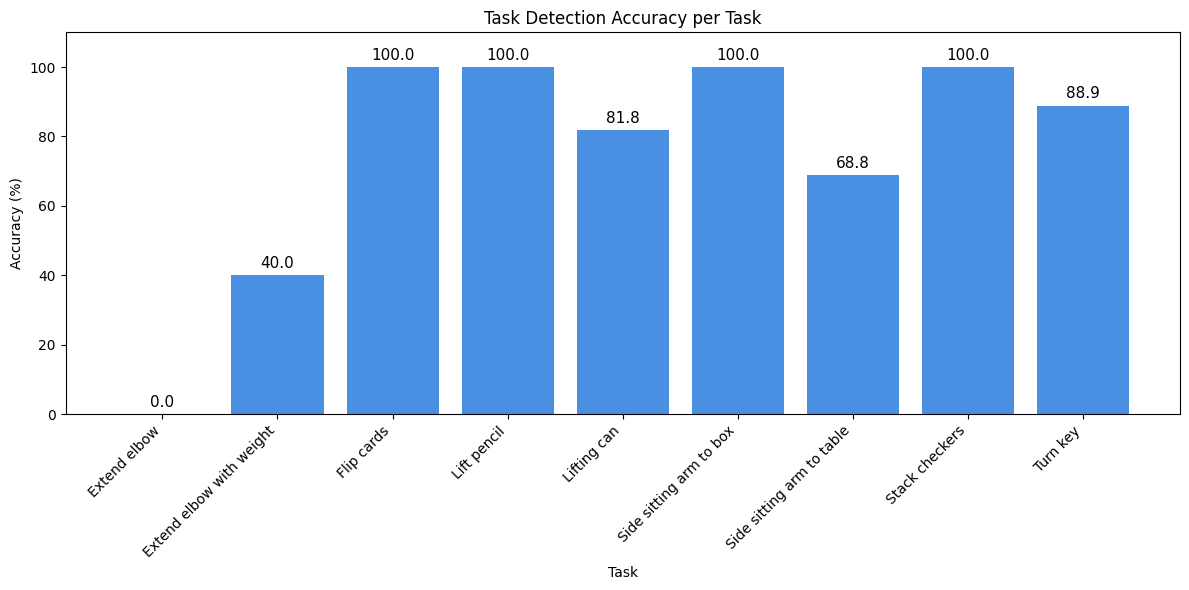

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'Ground_Truth_Score' in df.columns:
    df_valid = df[df['Ground_Truth_Score'] != "NO_INFO"].copy()
else:
    df_valid = df.copy()


df_valid = df_valid.dropna(subset=['Task', 'Detected_Task'])

acc_df = (
    df_valid
    .assign(Correct=lambda d: d['Task'] == d['Detected_Task'])
    .groupby('Task', as_index=False)['Correct'].mean()
    .rename(columns={'Correct': 'Accuracy'})
)
acc_df['Accuracy'] *= 100


plt.figure(figsize=(12,6))
ax = plt.gca()
bars = ax.bar(acc_df['Task'], acc_df['Accuracy'], color="#4A90E2")

ax.set_xlabel('Task')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Task Detection Accuracy per Task')
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, acc_df['Accuracy']):
    height = bar.get_height()
    ax.annotate(f"{val:.1f}",
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


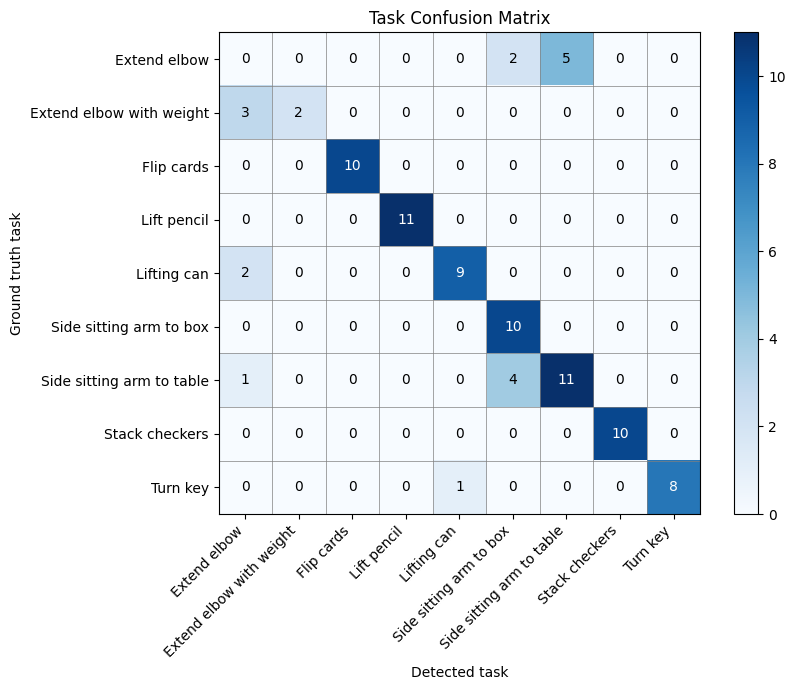

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confusion matrix
labels = sorted(set(df['Task']).union(set(df['Detected_Task'])))
cm = pd.crosstab(df['Task'], df['Detected_Task']).reindex(index=labels, columns=labels, fill_value=0)

plt.figure(figsize=(9,7))
ax = plt.gca()
im = ax.imshow(cm.values, cmap='Blues')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel("Detected task")
ax.set_ylabel("Ground truth task")
ax.set_title("Task Confusion Matrix")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm.values[i, j]
        if val >= 0:
            color = "white" if im.norm(val) > 0.5 else "black"
            ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=10)


ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.colorbar(im)
plt.tight_layout()
plt.show()


In [ ]:
high_acc_tasks = set(acc_df.loc[acc_df['Accuracy'] > 80, 'Task'])

df2 = df.copy()
df2['GT_Numeric'] = pd.to_numeric(df2['Ground_Truth_Score'], errors='coerce')
df2['Det_Numeric'] = pd.to_numeric(df2['Detected_Score'], errors='coerce')
df2 = df2.dropna(subset=['GT_Numeric', 'Det_Numeric'])

mae_df = (
    df2.groupby('Task')
       .apply(lambda g: np.mean(np.abs(g['Det_Numeric'] - g['GT_Numeric'])))
       .reset_index(name='MAE')
)


filtered_mae = mae_df[mae_df['Task'].isin(high_acc_tasks)]


plt.figure(figsize=(11,5))
ax = plt.gca()

bars = ax.bar(filtered_mae['Task'], filtered_mae['MAE'], color="#4A90E2", width=0.5)

ax.set_title('MAE by Task')
ax.set_ylabel('MAE')
ax.set_xlabel('Task')
ax.set_ylim(0, 5)
ax.set_yticks(range(0, 6))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

for rect, val in zip(bars, filtered_mae['MAE']):
    ax.annotate(f"{val:.2f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


/tmp/ipython-input-1950423709.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ((g['GT_Numeric'] == g['Det_Numeric']).mean() * 100))


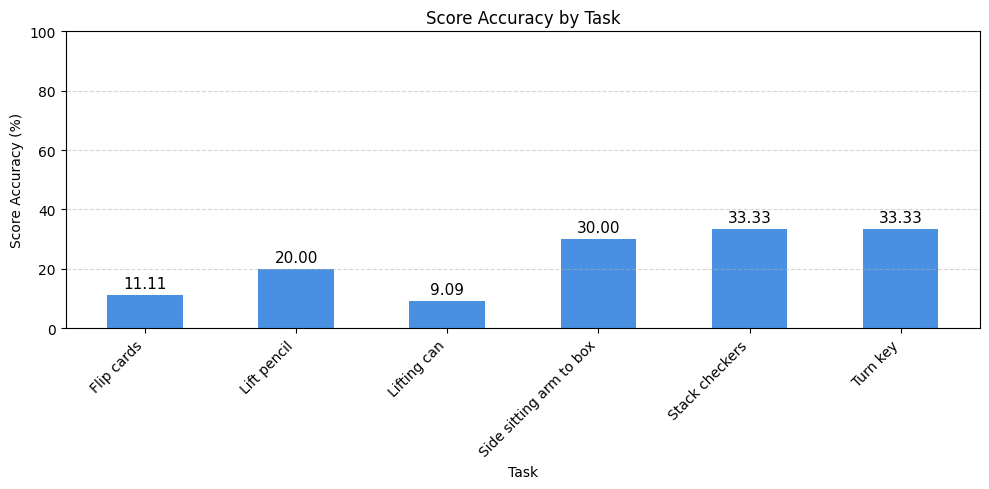

In [ ]:
df2 = df.copy()
df2['GT_Numeric'] = pd.to_numeric(df2['Ground_Truth_Score'], errors='coerce')
df2['Det_Numeric'] = pd.to_numeric(df2['Detected_Score'], errors='coerce')
df2 = df2.dropna(subset=['GT_Numeric', 'Det_Numeric'])

score_acc = (
    df2.groupby("Task")
       .apply(lambda g: ((g['GT_Numeric'] == g['Det_Numeric']).mean() * 100))
       .reset_index(name="Exact_Accuracy")
)


#Tasks with detection accuracy > 80%
high_acc_tasks = set(acc_df.loc[acc_df['Accuracy'] > 80, 'Task'])
score_acc_filtered = score_acc[score_acc['Task'].isin(high_acc_tasks)]

plt.figure(figsize=(10,5))
ax = plt.gca()
bars = ax.bar(score_acc_filtered['Task'], score_acc_filtered['Exact_Accuracy'],
              color="#4A90E2", width=0.5)

ax.set_ylabel('Score Accuracy (%)')
ax.set_xlabel('Task')
ax.set_title('Score Accuracy by Task')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

for rect, val in zip(bars, score_acc_filtered['Exact_Accuracy']):
    ax.annotate(f"{val:.2f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


/tmp/ipython-input-3131009952.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ((np.abs(g['GT_Numeric'] - g['Det_Numeric']) <= 1).mean() * 100))


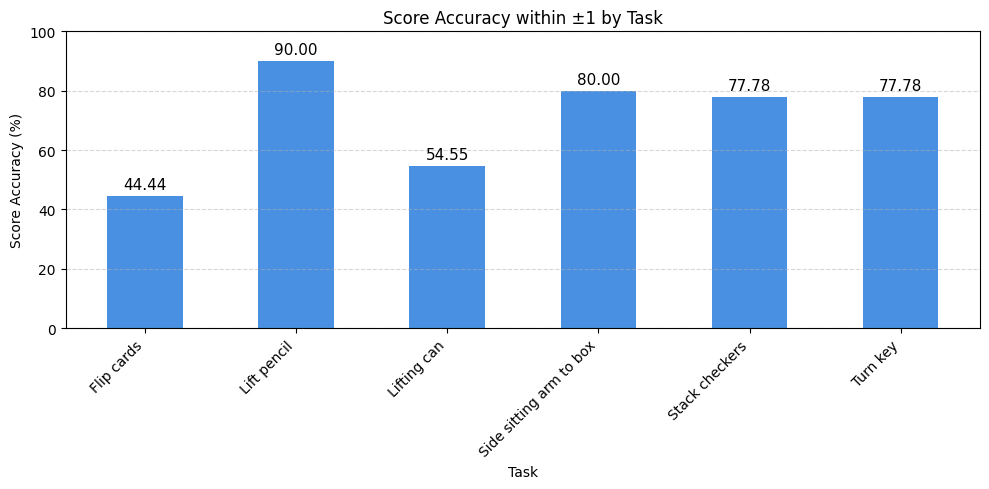

In [ ]:
df2 = df.copy()
df2['GT_Numeric'] = pd.to_numeric(df2['Ground_Truth_Score'], errors='coerce')
df2['Det_Numeric'] = pd.to_numeric(df2['Detected_Score'], errors='coerce')
df2 = df2.dropna(subset=['GT_Numeric', 'Det_Numeric'])

# Compute ±1 accuracy per task
score_within1 = (
    df2.groupby("Task")
       .apply(lambda g: ((np.abs(g['GT_Numeric'] - g['Det_Numeric']) <= 1).mean() * 100))
       .reset_index(name="Within1_Accuracy")
)

high_acc_tasks = set(acc_df.loc[acc_df['Accuracy'] > 80, 'Task'])
score_within1_filtered = score_within1[score_within1['Task'].isin(high_acc_tasks)]

plt.figure(figsize=(10,5))
ax = plt.gca()
bars = ax.bar(score_within1_filtered['Task'], score_within1_filtered['Within1_Accuracy'],
              color="#4A90E2", width=0.5)

ax.set_ylabel('Score Accuracy (%)')
ax.set_xlabel('Task')
ax.set_title('Score Accuracy within ±1 by Task')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

for rect, val in zip(bars, score_within1_filtered['Within1_Accuracy']):
    ax.annotate(f"{val:.2f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()
